<div align='center'>
<img src='https://www.funcionpublica.gov.co/documents/d/guest/logo-universidad-nacional' width='520'/>

---
**Universidad Nacional de Colombia — Sede Manizales**  
Facultad de Ingeniería y Arquitectura  
Departamento de Ingeniería Eléctrica, Electrónica y Computación  
*Procesamiento Digital de Imágenes*

**Profesor:** Lucas Iturriago  
**Autores:** Juan Camilo Giraldo Jiménez `1055750098` · Nicolás Castaño Pérez `1054398549`

</div>

# Detección Automática de Baches Viales mediante YOLOv8n
### *Un enfoque de aprendizaje profundo para el diagnóstico del estado del pavimento*

---

## Abstract

Este proyecto presenta un sistema completo de detección de baches viales (*potholes*) basado en la arquitectura **YOLOv8 Nano**, entrenada sobre un corpus de imágenes de asfalto deteriorado. El trabajo cubre el ciclo completo de un proyecto de visión artificial de alto impacto: adquisición y validación del dataset, configuración del pipeline de datos, entrenamiento con transferencia de conocimiento (*fine-tuning*), evaluación cuantitativa mediante métricas estándar de detección de objetos, y despliegue como aplicación web interactiva en Hugging Face Spaces.

A lo largo del notebook se incluyen fundamentos matemáticos que contextualizan cada etapa del procesamiento: desde la representación tensorial de la imagen digital hasta las funciones de pérdida que guían la optimización del modelo.

---

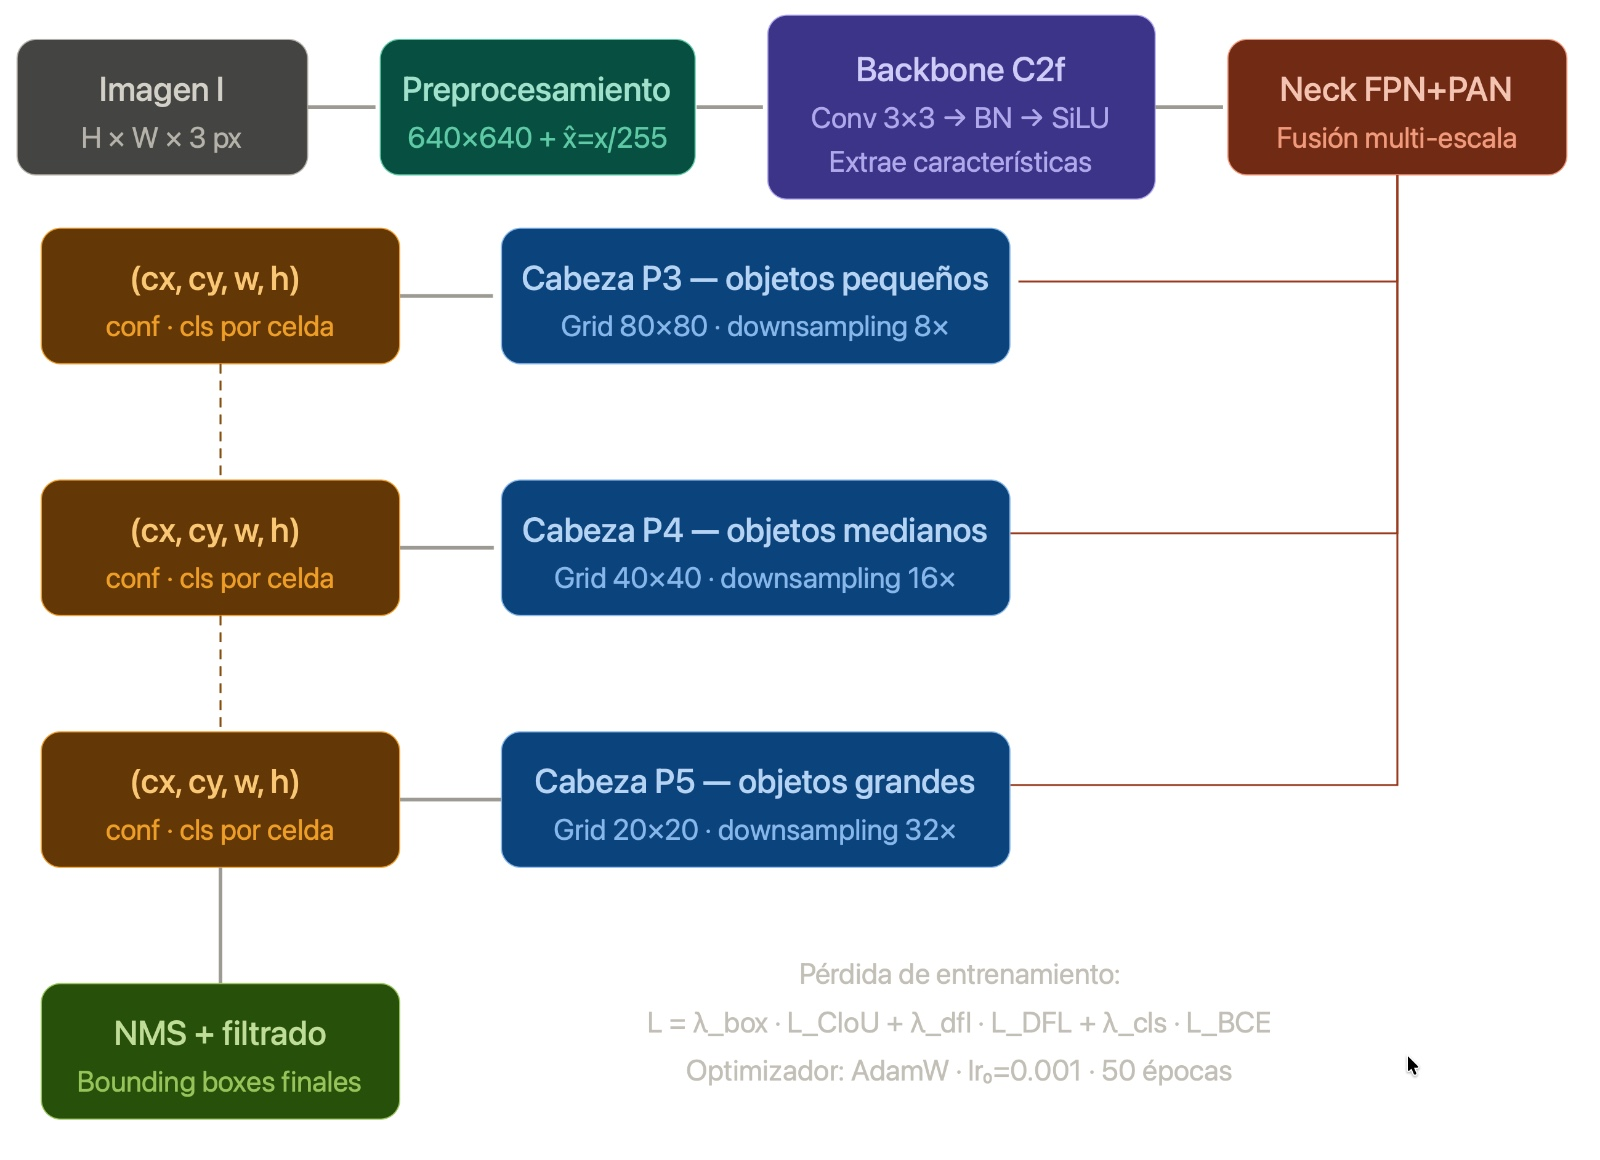

# Justificación Técnica: Arquitectura y Optimización

### 1. ¿Por qué utilizar YOLOv8n (Nano)?
La selección del modelo `yolov8n.pt` para la detección de baches viales responde a un equilibrio estricto entre rendimiento analítico y viabilidad de despliegue en hardware real. Las razones principales son:

* **Eficiencia Computacional y Edge AI:** La versión "Nano" es la más ligera de la familia YOLOv8, diseñada para maximizar la velocidad de inferencia (FPS) minimizando el consumo de RAM y VRAM. Esto es indispensable para un proyecto que busca compilar el modelo final mediante ExecuTorch para su potencial ejecución en microcontroladores, Raspberry Pi o cámaras embebidas en vehículos.
* **Arquitectura *Anchor-Free*:** A diferencia de las generaciones anteriores (YOLOv5), YOLOv8 no utiliza cajas ancla (*anchors*) predefinidas. Opera directamente sobre las celdas de la grilla espacial, lo que reduce drásticamente la carga computacional y mejora la flexibilidad para detectar baches de tamaños y proporciones muy irregulares.
* **Transferencia de Conocimiento (*Fine-Tuning*):** Al inicializar la red con pesos preentrenados en el dataset COCO (80 clases genéricas), el *backbone* ya posee filtros convolucionales maduros para detectar texturas, gradientes y bordes. Esto permite que el modelo converja rápidamente hacia el dominio específico del "asfalto deteriorado" empleando pocas épocas (50) y un conjunto de datos reducido.

### 2. Función de Pérdida Combinada
El aprendizaje de la red no depende de una sola métrica, sino que minimiza simultáneamente tres objetivos independientes para garantizar que la ubicación y la clasificación del bache sean exactas. La pérdida total se rige por la siguiente ecuación:

$$\mathcal{L}_{\text{total}} = \lambda_{\text{box}} \cdot \mathcal{L}_{\text{CIoU}} + \lambda_{\text{dfl}} \cdot \mathcal{L}_{\text{DFL}} + \lambda_{\text{cls}} \cdot \mathcal{L}_{\text{BCE}}$$

Donde cada término tiene un propósito específico:

* **Pérdida de Localización ($\mathcal{L}_{\text{CIoU}}$):** Utiliza la *Complete Intersection over Union*. Supera a la IoU tradicional porque, además de medir el solapamiento, penaliza la distancia entre el centro de la caja predicha y la real, así como las diferencias en la relación de aspecto (ancho/alto).
* **Pérdida de Distribución ($\mathcal{L}_{\text{DFL}}$):** La *Distribution Focal Loss* modela los bordes de la caja delimitadora como una distribución de probabilidad en lugar de coordenadas exactas. Es vital para este proyecto, ya que los baches no tienen bordes rectos o perfectamente definidos.
* **Pérdida de Clasificación ($\mathcal{L}_{\text{BCE}}$):** Aplica *Binary Cross-Entropy* por cada celda para determinar la probabilidad de que el objeto encapsulado pertenezca efectivamente a la clase "bache".

## Sección 1 — Preparación del Entorno de Desarrollo

### 1.1 Justificación de las dependencias

| Paquete | Versión mínima | Rol |
|---|---|---|
| `ultralytics` | 8.2 | Implementación oficial de YOLOv8: entrenamiento, validación e inferencia |
| `kagglehub` | 0.3 | Descarga programática de datasets desde Kaggle con versionado |
| `gradio` | 4.36 | Framework para construir la interfaz web interactiva |
| `huggingface_hub` | 0.23 | API para autenticación y upload de artefactos al Space |
| `pyyaml` | 6.0 | Lectura y escritura del archivo de configuración `data.yaml` |

La instalación se restringe al entorno de ejecución de Colab y no modifica dependencias del sistema operativo.

In [1]:
# ─────────────────────────────────────────────────────────────────────
# Sección 1 — Entorno de Desarrollo (local / Apple Silicon)
# ─────────────────────────────────────────────────────────────────────
# Las dependencias ya están instaladas en el entorno virtual (.venv).
# Para reinstalarlas:  pip install -r requirements.txt
import os, yaml, json
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import torch
from ultralytics import YOLO
from huggingface_hub import HfApi, login
from pathlib import Path

# Selección de dispositivo: CUDA (NVIDIA) > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = 'cuda'
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
    print(f"[INFO] VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif torch.backends.mps.is_available():
    device = 'mps'
    print("[INFO] Acelerador: Apple Silicon GPU (MPS)")
else:
    device = 'cpu'
    print("[INFO] Acelerador: CPU")

print(f"[INFO] Dispositivo de cómputo: {device}")
print("[OK] Entorno listo.")

/Users/nicocasper/digital_image_processing/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Acelerador: Apple Silicon GPU (MPS)
[INFO] Dispositivo de cómputo: mps
[OK] Entorno listo.


## Sección 2 — Adquisición y Análisis Exploratorio del Dataset

### 2.1 Descripción del corpus

Utilizamos el dataset **[Potholes Detection YOLOv8](https://www.kaggle.com/datasets/anggadwisunarto/potholes-detection-yolov8)**, disponible en Kaggle. El conjunto de datos contiene imágenes de vías capturadas en condiciones variables de iluminación, ángulo de cámara y estado del pavimento, anotadas en formato YOLO (coordenadas normalizadas de bounding box).

Cada anotación tiene la forma:

$$\text{Etiqueta}: \quad (c,\; x_{c},\; y_{c},\; w,\; h) \in \{0\} \times [0,1]^4$$

donde $c=0$ representa la clase *pothole*, y las coordenadas están normalizadas con respecto al ancho $W$ y alto $H$ de la imagen:

$$x_c = \frac{x_{\text{left}} + w_{\text{box}}/2}{W}, \quad
  y_c = \frac{y_{\text{top}} + h_{\text{box}}/2}{H}, \quad
  w   = \frac{w_{\text{box}}}{W}, \quad
  h   = \frac{h_{\text{box}}}{H}$$

### 2.2 Partición del corpus

| Split | Propósito |
|---|---|
| `train/` | Ajuste de pesos mediante retropropagación |
| `valid/` | Monitoreo de generalización durante el entrenamiento (early stopping) |
| `test/`  | Evaluación final sin sesgos de selección de hiperparámetros |

In [2]:
# ─────────────────────────────────────────────────────────────────────
# Sección 2 — Dataset local
# ─────────────────────────────────────────────────────────────────────
# Se usa el dataset incluido en el proyecto (./dataset).
# Para descargarlo desde Kaggle en su lugar, descomenta:
# dataset_path = Path(kagglehub.dataset_download("anggadwisunarto/potholes-detection-yolov8"))
dataset_path = Path("dataset").resolve()
print(f"[OK] Dataset en: {dataset_path}")

# Análisis estructural de la carpeta
for split in ['train', 'valid', 'test']:
    img_dir = dataset_path / split / 'images'
    lbl_dir = dataset_path / split / 'labels'
    n_imgs  = len(list(img_dir.glob('*.jpg'))) + len(list(img_dir.glob('*.png'))) if img_dir.exists() else 0
    n_lbls  = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f"  {split:6s}: {n_imgs:4d} imágenes  |  {n_lbls:4d} etiquetas")

[OK] Dataset en: /Users/nicocasper/digital_image_processing/dataset
  train : 1581 imágenes  |  1581 etiquetas
  valid :  396 imágenes  |   396 etiquetas
  test  :    0 imágenes  |     0 etiquetas


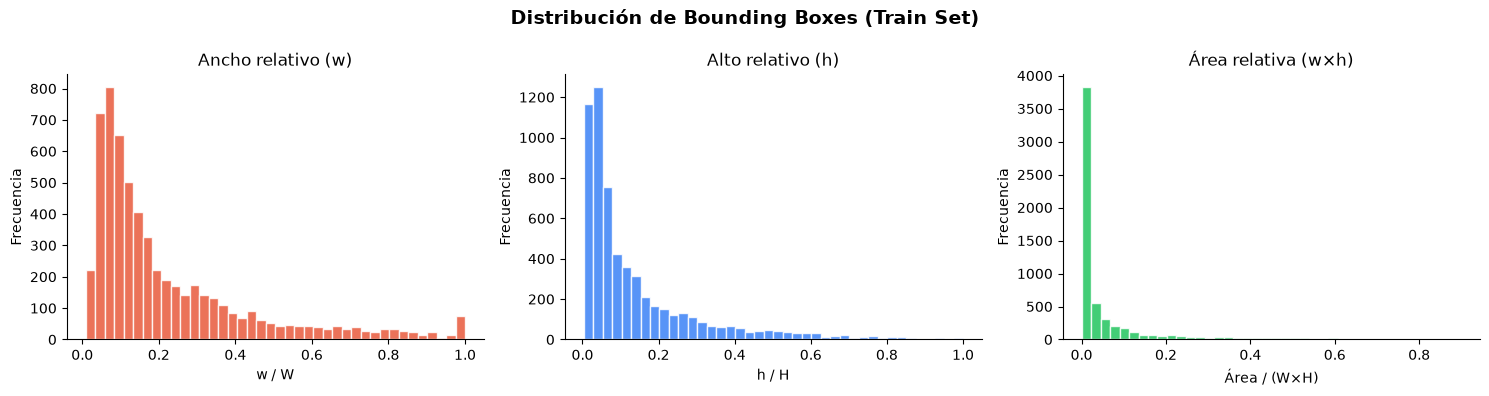

Total de anotaciones: 5942
Área media:           0.0592  |  Mediana: 0.0090
Área mín/máx:         0.0000 / 0.8991


In [3]:
# ─────────────────────────────────────────────────────────────────────
# Análisis Exploratorio: distribución de tamaños de bounding boxes
# ─────────────────────────────────────────────────────────────────────
import glob

label_files = glob.glob(str(Path(dataset_path) / 'train' / 'labels' / '*.txt'))
widths, heights, areas = [], [], []

for lf in label_files:
    with open(lf) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                _, xc, yc, w, h = map(float, parts)
                widths.append(w)
                heights.append(h)
                areas.append(w * h)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribución de Bounding Boxes (Train Set)', fontsize=14, fontweight='bold')

axes[0].hist(widths,  bins=40, color='#E8593C', edgecolor='white', alpha=0.85)
axes[0].set_title('Ancho relativo (w)');  axes[0].set_xlabel('w / W')

axes[1].hist(heights, bins=40, color='#3B82F6', edgecolor='white', alpha=0.85)
axes[1].set_title('Alto relativo (h)');   axes[1].set_xlabel('h / H')

axes[2].hist(areas,   bins=40, color='#22C55E', edgecolor='white', alpha=0.85)
axes[2].set_title('Área relativa (w×h)'); axes[2].set_xlabel('Área / (W×H)')

for ax in axes:
    ax.set_ylabel('Frecuencia')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total de anotaciones: {len(areas)}")
print(f"Área media:           {np.mean(areas):.4f}  |  Mediana: {np.median(areas):.4f}")
print(f"Área mín/máx:         {min(areas):.4f} / {max(areas):.4f}")

## Creación de imágenes de ejemplo para Hugging Face Space

In [4]:
# ─────────────────────────────────────────────────────────────────────
# Creación de imágenes de ejemplo para Hugging Face Space
# ─────────────────────────────────────────────────────────────────────
import os
import shutil

valid_images = os.path.join(dataset_path, "valid", "images")

os.makedirs("examples", exist_ok=True)

example_files = [
    "pothole_85.jpg",
    "pothole_666.jpg",
    "pothole_1090.jpg",
    "pothole_1092.jpg",
]

for img in example_files:
    src = os.path.join(valid_images, img)
    dst = os.path.join("examples", img)

    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"[OK] Copiada: {img}")

print("\n[OK] Carpeta examples creada.")
print("Contenido:")
print(os.listdir("examples"))

[OK] Copiada: pothole_85.jpg
[OK] Copiada: pothole_666.jpg
[OK] Copiada: pothole_1090.jpg

[OK] Carpeta examples creada.
Contenido:
['pothole_1090.jpg', 'pothole_666.jpg', 'pothole_85.jpg']


## Sección 3 — Ingeniería de Configuración (Data Pipeline)

### 3.1 El archivo `data.yaml`

YOLO espera un archivo YAML que especifique rutas absolutas al dataset y los nombres de clase. Dado que los archivos descargados por `kagglehub` son de **solo lectura** (mounted en un sistema de archivos inmutable), el flujo correcto es:

1. Leer el YAML original con `yaml.safe_load`.
2. Sobrescribir el campo `path` con la ruta absoluta del entorno Colab.
3. Serializar el YAML modificado en ``data_local.yaml``, que sí es escribible.

Este patrón garantiza la **reproducibilidad** del experimento: el script puede ejecutarse en cualquier instancia Colab sin intervención manual.

In [5]:
# ─────────────────────────────────────────────────────────────────────
# Sección 3 — Configuración del data.yaml
# ─────────────────────────────────────────────────────────────────────
original_yaml_path = os.path.join(dataset_path, 'data.yaml')

with open(original_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Asegurar rutas absolutas del entorno de ejecución
data_config['path']  = str(dataset_path)
data_config['train'] = 'train/images'
data_config['val']   = 'valid/images'

# Verificar que existe el campo 'nc' (número de clases)
assert 'nc' in data_config, "El YAML no contiene el campo 'nc' (número de clases)."
assert 'names' in data_config, "El YAML no contiene el campo 'names' (nombres de clase)."

new_yaml_path = 'data_local.yaml'
with open(new_yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"[OK] data.yaml guardado en: {new_yaml_path}")
print(f"     Clases ({data_config['nc']}): {data_config['names']}")
print(f"     Split train : {data_config.get('train')}")
print(f"     Split val   : {data_config.get('val')}")

[OK] data.yaml guardado en: data_local.yaml
     Clases (1): ['pothole']
     Split train : train/images
     Split val   : valid/images


## Sección 4 — Fundamentos Matemáticos del Procesamiento Tensorial

### 4.1 Representación digital de la imagen

Una imagen de color se representa como un tensor tridimensional:

$$I \in \mathbb{R}^{H \times W \times 3}$$

donde $H$ y $W$ son las dimensiones espaciales (alto y ancho en píxeles) y $3$ son los canales de color RGB. Cada valor $I[i,j,c] \in [0, 255]$ representa la intensidad luminosa del píxel $(i,j)$ en el canal $c \in \{R, G, B\}$.

### 4.2 Preprocesamiento: normalización y redimensionamiento

Antes de ingresar al modelo, la imagen es **redimensionada** a $640 \times 640$ px mediante *letterbox padding* (preservando la relación de aspecto) y **normalizada** por canal:

$$\hat{I}[i,j,c] = \frac{I[i,j,c]}{255}$$

produciendo valores en $[0, 1]$, lo cual estabiliza numéricamente el entrenamiento.

### 4.3 Operación de Convolución 2D

El núcleo del backbone de YOLOv8 son las capas de **convolución discreta**. Para un mapa de características de entrada $X \in \mathbb{R}^{H' \times W' \times C_{in}}$ y un filtro $K \in \mathbb{R}^{k \times k \times C_{in} \times C_{out}}$:

$$Y[i,j,n] = \sum_{c=1}^{C_{in}} \sum_{p=0}^{k-1} \sum_{q=0}^{k-1} K[p,q,c,n] \cdot X[i+p,\; j+q,\; c] + b_n$$

donde $n \in [1, C_{out}]$ índica el canal de salida (mapa de características). Los filtros $K$ son **aprendidos** durante el entrenamiento: en capas tempranas detectan bordes y gradientes de textura; en capas profundas codifican conceptos semánticos complejos como "bache".

### 4.4 Normalización por Lotes (Batch Normalization)

Después de cada convolución, se aplica **BatchNorm** para acelerar la convergencia y reducir la sensibilidad a la tasa de aprendizaje:

$$\hat{y}_i = \frac{y_i - \mu_{\mathcal{B}}}{\sqrt{\sigma^2_{\mathcal{B}} + \varepsilon}}, \qquad
  z_i = \gamma \hat{y}_i + \beta$$

donde $\mu_{\mathcal{B}}$ y $\sigma^2_{\mathcal{B}}$ son la media y varianza del mini-batch, y $\gamma, \beta$ son parámetros aprendibles de escala y desplazamiento.

### 4.5 Función de Activación SiLU

YOLOv8 emplea la activación **SiLU** (*Sigmoid Linear Unit*), también conocida como Swish:

$$\text{SiLU}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

A diferencia de ReLU (que anula todos los valores negativos), SiLU es **suave, no monótona y diferenciable en todo su dominio**, lo que produce gradientes de mejor calidad durante la retropropagación.

### 4.6 Cabezas de Predicción Anchor-Free

YOLOv8 abandona los *anchors* predefinidos de versiones anteriores. En su lugar, opera directamente sobre tres escalas de grillas con factores de submuestreo $s \in \{8, 16, 32\}$, generando mapas de predicción de tamaño $\left\lfloor \frac{H}{s} \right\rfloor \times \left\lfloor \frac{W}{s} \right\rfloor$.

Para cada celda $(i,j)$ de la grilla, la cabeza predice:

$$\hat{y}_{ij} = (\hat{x}_c, \hat{y}_c, \hat{w}, \hat{h},\; \hat{conf},\; \hat{p}_0, \ldots, \hat{p}_{C-1})$$

donde $\hat{x}_c, \hat{y}_c$ son desplazamientos respecto al centro de la celda, y la distribución de bordes de la caja se modela mediante **DFL** (Distribution Focal Loss).

## Sección 5 — Función de Pérdida Combinada de YOLOv8

El entrenamiento de YOLOv8 minimiza simultáneamente tres objetivos:

$$\mathcal{L}_{\text{total}} = \lambda_{\text{box}} \cdot \mathcal{L}_{\text{CIoU}} + \lambda_{\text{dfl}} \cdot \mathcal{L}_{\text{DFL}} + \lambda_{\text{cls}} \cdot \mathcal{L}_{\text{BCE}}$$

con pesos por defecto $\lambda_{\text{box}} = 7.5$, $\lambda_{\text{dfl}} = 1.5$, $\lambda_{\text{cls}} = 0.5$.

### 5.1 Pérdida de Localización — CIoU

La **Complete IoU Loss** extiende la IoU estándar penalizando tres factores adicionales: solapamiento insuficiente, distancia entre centros y disparidad de relación de aspecto:

$$\mathcal{L}_{\text{CIoU}} = 1 - \text{IoU} + \frac{\rho^2(b, b^{gt})}{c^2} + \alpha v$$

donde:
- $\rho^2(b, b^{gt})$ = distancia euclidiana al cuadrado entre centros predicho y real
- $c^2$ = diagonal al cuadrado de la caja envolvente mínima de ambas cajas
- $v = \frac{4}{\pi^2}\left(\arctan\frac{w^{gt}}{h^{gt}} - \arctan\frac{w}{h}\right)^2$ = término de consistencia de aspecto
- $\alpha = \frac{v}{(1 - \text{IoU}) + v}$ = factor de ponderación adaptativo

### 5.2 Pérdida de Distribución — DFL

YOLOv8 modela cada borde de la bounding box como una distribución discreta de probabilidad sobre $n$ bins. La **Distribution Focal Loss** supervisa esta distribución:

$$\mathcal{L}_{\text{DFL}}(S_i, S_{i+1}) = -\left[(y_{i+1} - y)\log S_i + (y - y_i)\log S_{i+1}\right]$$

donde $y_i \leq y < y_{i+1}$ son los bins que flanquean el valor real de la coordenada.

### 5.3 Pérdida de Clasificación — BCE

Para la clasificación multi-etiqueta de cada celda, se emplea la **Binary Cross-Entropy** aplicada independientemente por clase:

$$\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log \hat{p}_i + (1 - y_i)\log(1 - \hat{p}_i)\right]$$

donde $y_i \in \{0,1\}$ es la etiqueta real y $\hat{p}_i \in (0,1)$ es la probabilidad predicha para la clase $i$.

## Sección 6 — Entrenamiento Optimizado de YOLOv8n

### 6.1 Estrategia de transferencia de conocimiento

Se utiliza el modelo preentrenado `yolov8n.pt` (entrenado en COCO de 80 clases) como punto de partida. Esto se conoce como **fine-tuning**: los pesos del backbone, que ya codifican características visuales genéricas (bordes, texturas, formas), se adaptan al dominio específico de detección de baches con muchos menos datos y épocas que un entrenamiento *from scratch*.

### 6.2 Hiperparámetros de entrenamiento

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `epochs` | 50 | Balance entre convergencia y tiempo GPU |
| `imgsz` | 640 | Resolución estándar YOLO; captura detalles finos de asfalto |
| `batch` | 16 | Óptimo para 15 GB VRAM (T4) |
| `optimizer` | `AdamW` | Convergencia más rápida y regularización implícita via weight decay |
| `lr0` | 0.001 | Tasa de aprendizaje inicial |
| `lrf` | 0.01 | Factor de decaimiento coseno final |
| `warmup_epochs` | 3 | Calentamiento lineal para evitar inestabilidad inicial |
| `mosaic` | 1.0 | Augmentación Mosaic: combina 4 imágenes en una para escala variada |
| `mixup` | 0.1 | Interpolación lineal de imágenes y etiquetas |
| `close_mosaic` | 10 | Desactiva Mosaic en las últimas 10 épocas para refinar |

In [6]:
# ─────────────────────────────────────────────────────────────────────
# Sección 6 — Entrenamiento del modelo
# ─────────────────────────────────────────────────────────────────────
model = YOLO('yolov8n.pt')  # Carga pesos COCO preentrenados (transferencia)

train_results = model.train(
    data        = new_yaml_path,
    epochs      = 50,            # ← ajustar según presupuesto de tiempo GPU
    imgsz       = 640,
    batch       = 16,
    optimizer   = 'AdamW',
    lr0         = 0.001,
    lrf         = 0.01,
    warmup_epochs = 3,
    mosaic      = 1.0,
    mixup       = 0.1,
    close_mosaic = 10,
    plots       = True,          # Genera curvas en runs/detect/train/
    save        = True,
    save_period = 10,            # Checkpoint cada 10 épocas
    project     = 'runs/detect',
    name        = 'train',
    exist_ok    = True,
    device      = device,        # Usa GPU si está disponible
    verbose     = True,
)

print("\n[OK] Entrenamiento finalizado.")
best_model_path = 'runs/detect/train/weights/best.pt'
print(f"[INFO] Mejores pesos guardados en: {best_model_path}")

Ultralytics 8.4.71 🚀 Python-3.12.12 torch-2.12.1 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data_local.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

## Sección 7 — Validación y Diagnóstico de Rendimiento

### 7.1 Marco teórico de evaluación

La calidad de un detector de objetos se cuantifica mediante métricas derivadas de la **Intersection over Union (IoU)**:

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{Área de intersección}}{\text{Área de unión}}$$

Una detección se clasifica como **True Positive (TP)** si $\text{IoU} \geq \theta_{\text{IoU}}$ (típicamente $0.5$ o $0.5{:}0.95$), como **False Positive (FP)** si $\text{IoU} < \theta_{\text{IoU}}$, y como **False Negative (FN)** si un objeto real no fue detectado.

### 7.2 Precision y Recall

$$P = \frac{TP}{TP + FP} \qquad \text{(¿Cuántas detecciones son correctas?)}$$

$$R = \frac{TP}{TP + FN} \qquad \text{(¿Cuántos baches reales fueron encontrados?)}$$

Existe un *trade-off* fundamental: aumentar el umbral de confianza $\tau$ incrementa $P$ pero reduce $R$.

### 7.3 Average Precision (AP) y mAP

La **Average Precision** es el área bajo la curva Precision-Recall, calculada integrando sobre todos los umbrales de confianza:

$$\text{AP} = \int_0^1 P(R)\, dR \approx \sum_{k=1}^{n} P(k)\cdot\Delta R(k)$$

La **mean Average Precision** promedia la AP sobre todas las clases $C$ del dataset:

$$\text{mAP} = \frac{1}{|C|} \sum_{c=1}^{|C|} \text{AP}_c$$

YOLOv8 reporta dos variantes estándar:
- **mAP@0.5**: umbral de IoU fijo en $0.5$ (más permisivo)
- **mAP@0.5:0.95**: promedio sobre umbrales de IoU en $[0.5, 0.95]$ con paso $0.05$ (más exigente, estándar COCO)

In [8]:
# ─────────────────────────────────────────────────────────────────────
# Sección 7 — Evaluación cuantitativa en el conjunto de validación
# ─────────────────────────────────────────────────────────────────────
best_model_path = '/Users/nicocasper/digital_image_processing/runs/detect/runs/detect/train/weights/best.pt'

best_model = YOLO(best_model_path)
metrics = best_model.val(
    data    = new_yaml_path,
    imgsz   = 640,
    conf    = 0.001,    # Umbral muy bajo para recuperar toda la curva P-R
    iou     = 0.60,
    plots   = True,
    save_json = False,
)

# ── Resumen de métricas ──────────────────────────────────────────────
print("\n" + "═"*48)
print("  RESUMEN DE MÉTRICAS — Conjunto de Validación")
print("═"*48)
print(f"  mAP @ IoU=0.50          : {metrics.box.map50:.4f}")
print(f"  mAP @ IoU=0.50:0.95     : {metrics.box.map:.4f}")
print(f"  Precision  media (P)    : {metrics.box.mp:.4f}")
print(f"  Recall     medio (R)    : {metrics.box.mr:.4f}")
print("═"*48)

# Guardar métricas en JSON para el Space
metrics_dict = {
    'map50':      round(float(metrics.box.map50), 4),
    'map5095':    round(float(metrics.box.map),   4),
    'precision':  round(float(metrics.box.mp),    4),
    'recall':     round(float(metrics.box.mr),    4),
}
with open('metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print("\n[OK] Métricas guardadas en metrics.json")

Ultralytics 8.4.71 🚀 Python-3.12.12 torch-2.12.1 CPU (Apple M3)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 439.0±162.1 MB/s, size: 168.0 KB)
val: Scanning /Users/nicocasper/digital_image_processing/dataset/valid/labels.cache... 395 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 396/396 28.2Mit/s 0.0s
val: /Users/nicocasper/digital_image_processing/dataset/valid/images/pothole_1870.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'dng', 'jp2', 'avif', 'jpg', 'tif', 'jpeg', 'tiff', 'webp', 'jpeg2000', 'png', 'mpo', 'heif', 'heic', 'bmp'}
videos: {'ts', 'webm', 'mpeg', 'avi', 'wmv', 'asf', 'mov', 'm4v', 'mpg', 'mkv', 'mp4', 'gif'}
val: /Users/nicocasper/digital_image_processing/dataset/valid/images/pothole_975.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25

🔍 Buscando artefactos visuales...

[INFO] Archivo no disponible: results.png (normal si no se activaron plots extra)

══════════════════════════════════════════════════
  🎯 Predicciones de Validación (Muestra)
══════════════════════════════════════════════════


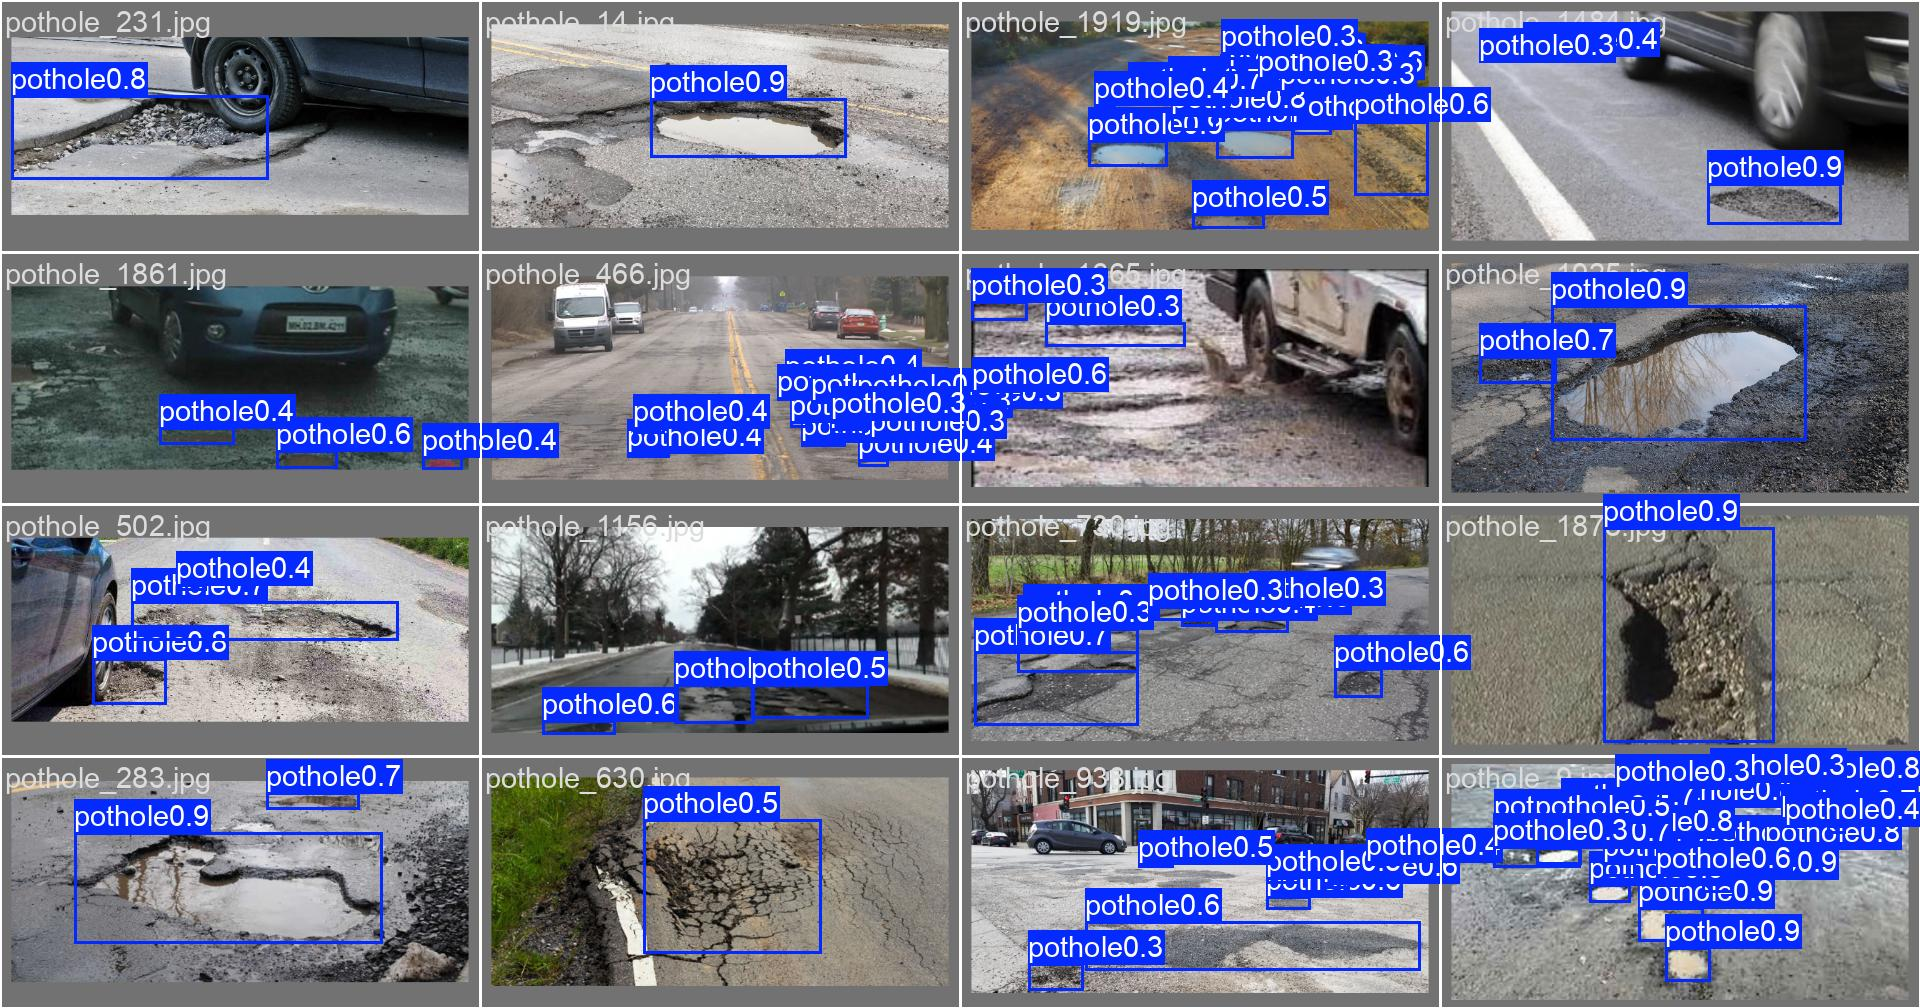


══════════════════════════════════════════════════
  📈 Curva Precision-Recall (Validación)
══════════════════════════════════════════════════


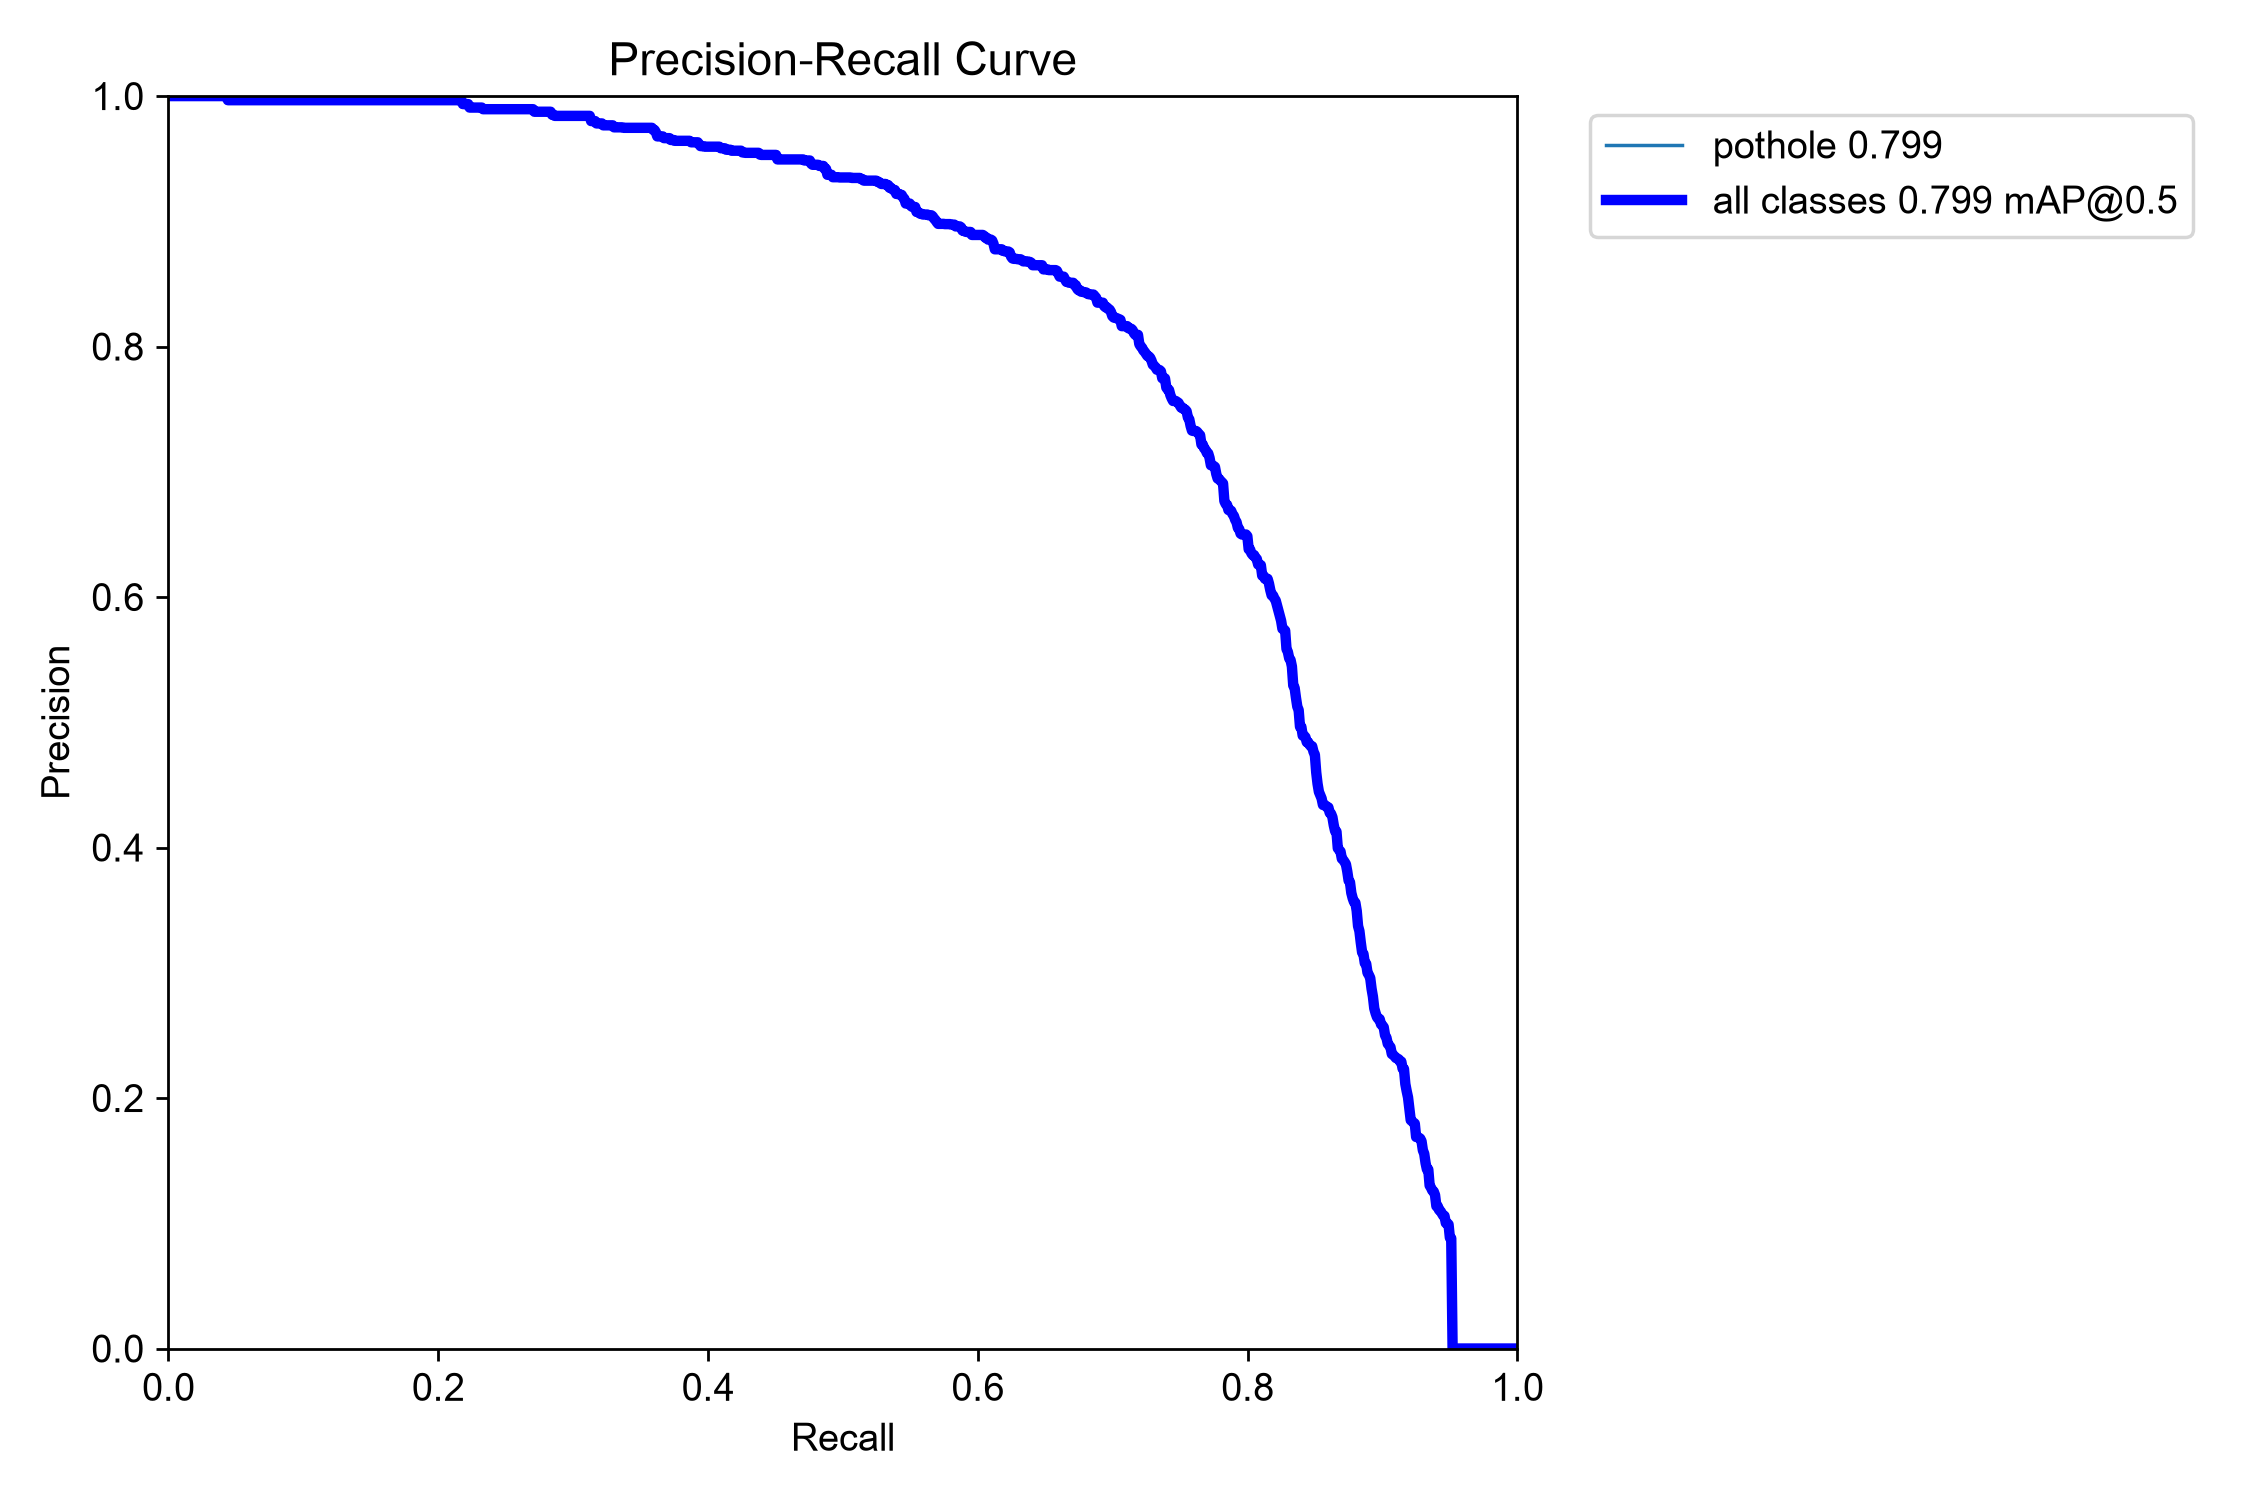


══════════════════════════════════════════════════
  📉 Curva F1-Confidence
══════════════════════════════════════════════════


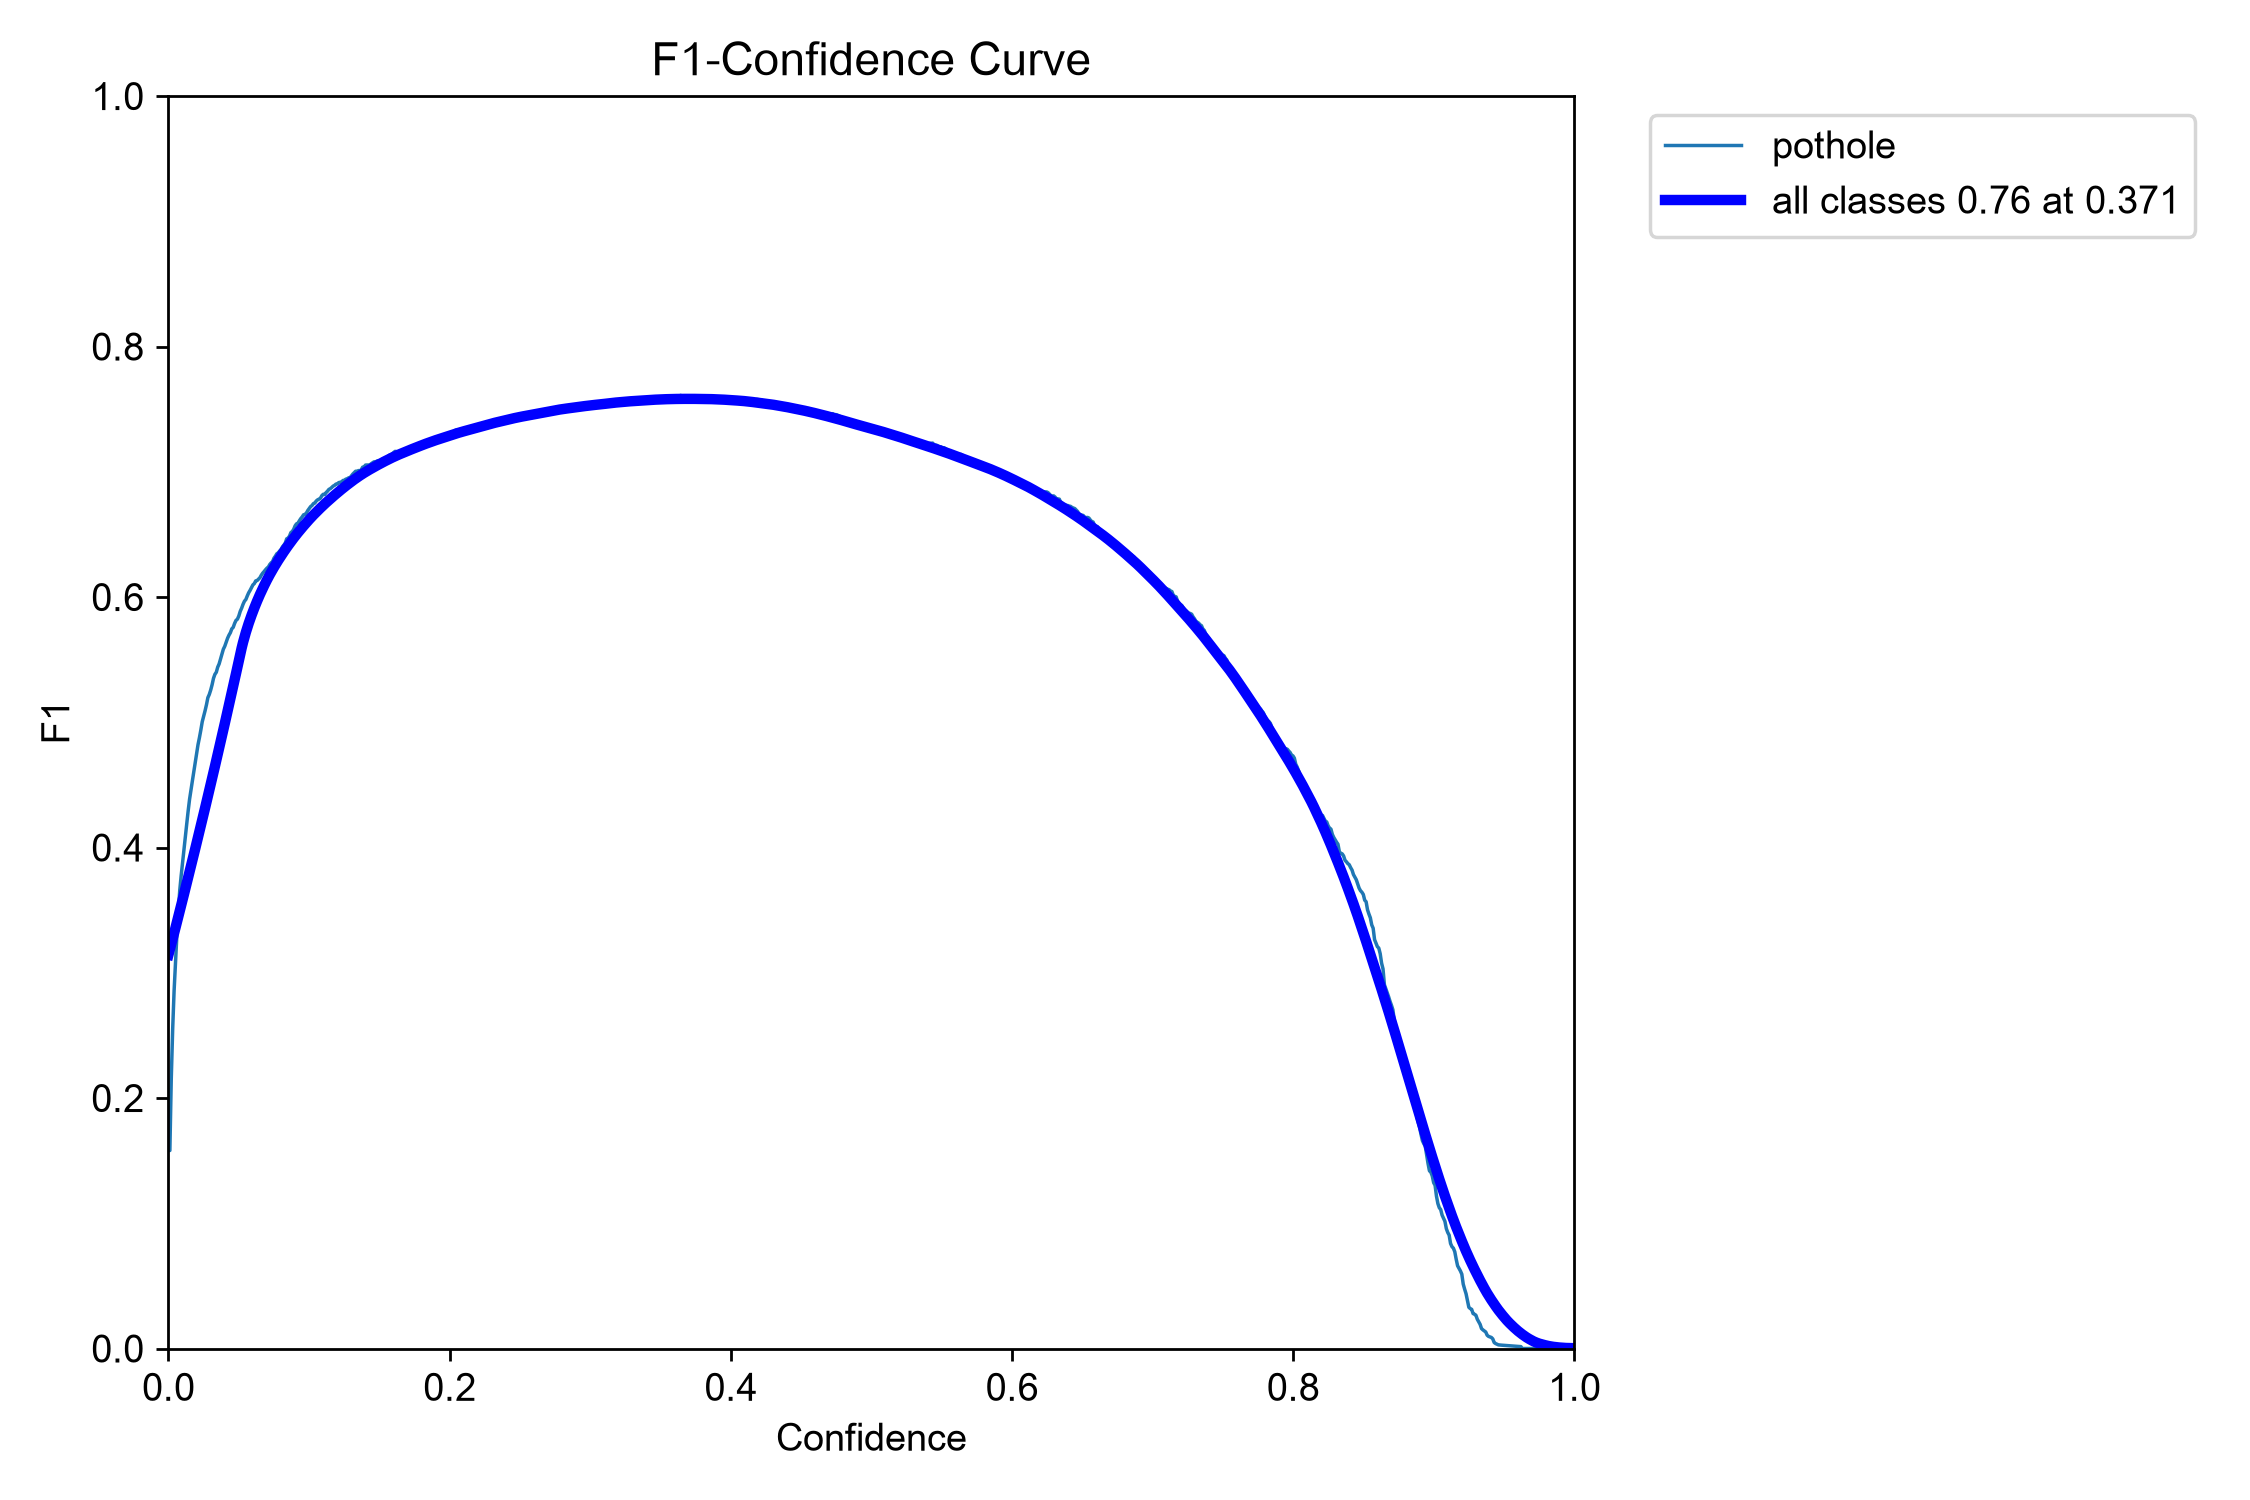

In [9]:
# ─────────────────────────────────────────────────────────────────────
# Visualización de curvas y resultados
# ─────────────────────────────────────────────────────────────────────
from IPython.display import Image as IPImage, display
import os

# Rutas de salida de YOLO
train_dir = 'runs/detect/train/'
val_dir = 'runs/detect/val/'

# Lista de archivos a intentar mostrar
curve_files = [
    (train_dir + 'results.png',         '📊 Curvas de Entrenamiento (Pérdida y mAP)'),
    (val_dir + 'val_batch0_pred.jpg',   '🎯 Predicciones de Validación (Muestra)'),
    (val_dir + 'BoxPR_curve.png',          '📈 Curva Precision-Recall (Validación)'),
    (val_dir + 'BoxF1_curve.png',          '📉 Curva F1-Confidence'),
]

print("🔍 Buscando artefactos visuales...\n")

for path, title in curve_files:
    if os.path.exists(path):
        print(f"\n{'═'*50}")
        print(f"  {title}")
        print(f"{'═'*50}")
        display(IPImage(path, width=800))
    else:
        alt_path = path.replace(val_dir, train_dir)
        if os.path.exists(alt_path):
             display(IPImage(alt_path, width=800))
        else:
             print(f"[INFO] Archivo no disponible: {os.path.basename(path)} (normal si no se activaron plots extra)")

## Sección 8 — Optimización y Despliegue en Edge (ExecuTorch)

### 8.1 Introducción a ExecuTorch

Para llevar modelos de visión artificial a dispositivos con recursos limitados (smartphones, microcontroladores o edge devices), no es eficiente utilizar el entorno completo de PyTorch. **ExecuTorch** es la arquitectura de próxima generación para el despliegue de modelos de IA en dispositivos móviles y de borde, optimizando el grafo de computación para reducir el consumo de memoria y energía.

### 8.2 Proceso de Exportación

El proceso de exportación realiza las siguientes transformaciones:

1.  **Trazado (Tracing):** Se convierte el código Python dinámico en un grafo estático de operaciones.
2.  **Optimización del Grafo:** Se eliminan operaciones redundantes y se fusionan capas (como Convolución y BatchNorm) para mejorar la velocidad.
3.  **Serialización:** El modelo se guarda en un formato binario eficiente compatible con el runtime de ExecuTorch.

### 8.3 Justificación técnica

| Característica | Beneficio |
|---|---|
| **Baja latencia** | Permite inferencia en tiempo real directamente en el dispositivo. |
| **Portabilidad** | El mismo archivo puede ejecutarse en iOS, Android y diversos sistemas embebidos. |
| **Eficiencia** | Minimiza el overhead del intérprete de Python, permitiendo una ejecución nativa. |

In [11]:
# ─────────────────────────────────────────────────────────────────────
# Sección 8 — Exportación Manual a ExecuTorch (.pte)
# ─────────────────────────────────────────────────────────────────────
import torch
from ultralytics import YOLO
from torch.export import export
import os

from executorch.exir import to_edge_transform_and_lower

print(f"[INFO] Entorno ExecuTorch listo (Torch {torch.__version__})")

# Ruta de los pesos entrenados
best_model_path = '/Users/nicocasper/digital_image_processing/runs/detect/runs/detect/train/weights/best.pt'

if os.path.exists(best_model_path):
    print("\n--- [1] PREPARANDO MODELO PARA EXECUTORCH ---")
    yolo_wrapper = YOLO(best_model_path)
    # La exportación se hace en CPU (ATen export es independiente del device)
    model = yolo_wrapper.model.cpu().fuse().eval()

    # Entrada de prueba estándar (1 imagen RGB 640x640)
    sample_input = (torch.randn(1, 3, 640, 640),)

    print("\n--- [2] CAPTURANDO GRAFO Y CONVIRTIENDO ---")
    exported_program = export(model, sample_input)
    edge_program = to_edge_transform_and_lower(exported_program)
    executorch_program = edge_program.to_executorch()

    dest_path = "best_baches.pte"
    with open(dest_path, "wb") as f:
        f.write(executorch_program.buffer)

    print(f"\n[ÉXITO TOTAL] Modelo guardado como '{dest_path}'")
else:
    print(f"[ERROR] No se encontró el archivo en {best_model_path}")

[INFO] Entorno ExecuTorch listo (Torch 2.12.1)

--- [1] PREPARANDO MODELO PARA EXECUTORCH ---
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

--- [2] CAPTURANDO GRAFO Y CONVIRTIENDO ---


/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.model.22.strides, self.model.22.anchors were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)
/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/nicocasper/d


[ÉXITO TOTAL] Modelo guardado como 'best_baches.pte'
